# BALD Simulation

In [1]:
# Azure ML Libraries
from azure.ai.ml.entities import Environment
from azure.identity import InteractiveBrowserCredential
from azure.ai.ml import MLClient, Input, Output, command
from azure.ai.ml import dsl
from azure.ai.ml.dsl import pipeline
from azure.ai.ml import load_component
from azure.ai.ml.entities._assets.environment import BuildContext, Environment

## Pipeline configuration

In [ ]:
# True if the pipeline should be subitted to aml
run_pipeline = True
allow_preprep_caching = False
create_with_schedule = False

# Relevant variables
compute_target_name = "gpu-cluster-small-2"
model_directory = ''
experiment_name = "trial_BALD_simulation"
schedule_name = f"{experiment_name}-schedule"

# ML Client
azure_config = {
    "subscription_id": "redacted",
    "resource_group": "redacted",
    "workspace_name": "redacted",
    "storage_account": "redacted"
    }

subscription_id = azure_config["subscription_id"]
resource_group = azure_config["resource_group"]
workspace_name = azure_config["workspace_name"]
storage_account = azure_config["storage_account"]

credential=InteractiveBrowserCredential()

ml_client = MLClient(credential=credential,
                     subscription_id=subscription_id,
                     resource_group_name=resource_group,
                     workspace_name=workspace_name)

# Check if the compute compute resource is available
compute_resource = ml_client.compute.get(compute_target_name)

#deployment enviroment: - set default always to "qa"
#env = ml_client.environments.get(name="amf_aml_test_env", version="3")
#env = Environment()

#Potentially switch to definition on the fly by including the requirements_aml.txt right in the variable

# Select the enviroment for the python script steps
# pipeline_job_env = Environment(
#     image="mcr.microsoft.com/azureml/minimal-ubuntu22.04-py39-cuda11.8-gpu-inference:latest",
#     conda_file="./requirements_aml.yml"


## Default Paths

In [ ]:
# All registered data sources can be accessed through the ml client.
# It is also possible to add new data, like the temporary ones created below.
ml_ds_id = ml_client.datastores.get(storage_account).id
base_path = f"azureml:/{ml_ds_id}/paths/raw".replace("providers/Microsoft.MachineLearningServices/", "")

# Config base paths
# BALD_dataset = base_path + r'/BALD_Simulation/'
# BALD_dataset = base_path + r'/252_csv_BALD_small_dataset/'
BALD_dataset = base_path + r'/252_csv_BALD/'

## Environment

In [ ]:
pipeline_job_env = ml_client.environments.get(name="amf_env_BALD", version="1") #Building the Environment in the UI allows for a specific Dockerfile to define commands, while using a conda yaml for further libraries.

# The following allows building an Environment from PythonSDK remotely.
# pipeline_job_env = Environment(
#     build=BuildContext(path='./environment_files/',             #if BuildContext is used, a conda filepath is not allowed. If a yaml with conda dependencies is ought to be used, an image needs to be specified first. In this case we need apt-get libvips however.
#     dockerfile_path = 'Dockerfile'                              #path specifies the folder which shall be uploaded in the context, whereas Dockerfile is the specific file for the customised Docker image.
#     ),
#     name="amf_train_env",
#     version="20",
#     description="training_environment",
#    )

# pipeline_job_env = Environment(
#     image="mcr.microsoft.com/azureml/openmpi4.1.0-ubuntu20.04",
#     name="amf_train_env",
#     version="8",
#     conda_file="./environment_files/requirements_aml.yml",
#     description="training_environment",
#    )

#pipeline_job_env.validate()

## Pipeline step definition

In [5]:
pipeline_BALD_simulation = command(
    name="amfinder_bald_simulation",
    display_name="",
    description="",
    code="../amf_code",                                      #Thats the code uploaded as a "repo" to Azure
    inputs={
        "images": Input(type="uri_folder"),                 #specify uri_folder as we are working with a cloud folder in fact
    },
    outputs={
        "training_outputs": Output(type="uri_folder"),
    },
    command="""
            conda run -n requirements_aml python BALD_Simulation.py \
            --data-dir \
            ${{inputs.images}} \
            """,
    environment=pipeline_job_env
)

#Potentially add  conda run -n requirements_aml pip install -r requirements_aml.txt && \ after conda run -n requirements_aml python amf_aml.py train \
#Running on amf_train_env environment version 27!

In [ ]:
@dsl.pipeline(
    default_compute=compute_target_name,
    experiment_name=experiment_name,
    description="AMF126_BALD_Simulation")
def pipeline_amftraining(
    images
):
    job_train_amf_model = pipeline_BALD_simulation(
        images = images
    )

    return {
    }


In [ ]:
pipeline = pipeline_amftraining(
    images = Input(type="uri_folder", path=BALD_dataset)
    )

pipeline_job = ml_client.jobs.create_or_update(
    pipeline,
    experiment_name=experiment_name,
    )


Class AutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class AutoDeleteConditionSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseAutoDeleteSettingSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class IntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class ProtectionLevelSchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class BaseIntellectualPropertySchema: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Your file exceeds 100 MB. If you exper

In [ ]:
f1_bald =  [0.06906717203621815, 0.06891480197499737, 0.06891480197499737, 0.14522939703054977, 0.16459945197127196, 0.13943449784526832, 0.16115698806121823, 0.14924897647235996, 0.19857346363102182, 0.19783056411803712, 0.24027627804668095, 0.28401266813817216, 0.2137524214290246, 0.2022985981584143, 0.1997538361273878, 0.29174696102084147, 0.22742962047322135, 0.3075337120781331, 0.2878896034021304, 0.2723783729224817, 0.2858223209397926, 0.2663916537715588, 0.28322639810082495, 0.2984689622046814, 0.28983522727483707, 0.28879809067742757, 0.2860266642070009, 0.34867676815936566, 0.31397934452663073, 0.287364370337902, 0.22343797088135087, 0.2989496290046268, 0.3167324601490838, 0.32276275233262536, 0.28630326836570513, 0.3286264084251949, 0.35182953748550366, 0.26182737579543464, 0.21971443288603784, 0.23871023209707334, 0.25653779717206676, 0.25061846519298714, 0.2308234620148695, 0.2576953428111071, 0.2764409666338797, 0.2662889185211663, 0.29539960147934474, 0.3126462483324935, 0.2955061012558427, 0.3045402260438853, 0.28853493729777946, 0.3217203645691113, 0.2799528178890401, 0.3031077928233347, 0.2818197542474305, 0.3034930948774475, 0.2976835922178343, 0.31024613337270596, 0.3169237732743067, 0.2762616228254015, 0.32378778157498783, 0.3061113536719516, 0.31583351917016556, 0.3028235859605236, 0.28621647788042576, 0.3196969009941243, 0.322207394747509, 0.31217212854104603, 0.34909581613933555, 0.31614303708652336, 0.3185582773755366, 0.35070969703899674, 0.3351147275583335, 0.3329236844178332, 0.337906074788812, 0.3069634860075124, 0.32869009575423663, 0.3033693080205894, 0.3515668598689701, 0.3197789881179421, 0.33299090969212924, 0.3349080657205205, 0.3296921037293252, 0.3445626101512523, 0.34699562169917697, 0.35392440135355385, 0.3327693206446927, 0.34851459223280373, 0.3174619087939054, 0.3179662929203621, 0.3659255794057394, 0.32924295341150994, 0.31474275277388825, 0.3182911837421794, 0.3475908979493801, 0.34449006138442767, 0.29783162045847605, 0.3442145480976049, 0.3276316131745556, 0.33694848718402154]
f1_random =  [0.06906717203621815, 0.23272315533454077, 0.1948134392314663, 0.17344712223108003, 0.28004807905382206, 0.2273320108971579, 0.2870594164447458, 0.2868710407087544, 0.2744403338516587, 0.27972656188862266, 0.2863139731276066, 0.285699950828006, 0.28300127539504677, 0.3334471115755581, 0.29197450005450953, 0.2790848242620599, 0.3102027744958029, 0.32628251695867555, 0.29539638891830394, 0.326170398281099, 0.33655787843305246, 0.3358599344199567, 0.3330795736669417, 0.3287493842318814, 0.3421729261417045, 0.33653451125685985, 0.33258061953671575, 0.35924669394393943, 0.34454831746176734, 0.3591310422241514, 0.334587546911544, 0.3426822479516963, 0.32951143332179733, 0.3593499106422662, 0.3232930529650855, 0.34599967522691794, 0.3191663591585156, 0.33618428040370607, 0.3126051868587938, 0.35083494066801096, 0.32990954855105026, 0.32246919216727077, 0.33024557160956497, 0.3380856732207995, 0.33091297761921545, 0.354200738093387, 0.360207974957556, 0.3370820097047224, 0.317656532857979, 0.16435895167708345, 0.3268643260801813, 0.3280020625245697, 0.3412016061781107, 0.3411063734955342, 0.3408816324475108, 0.34536783928126136, 0.340617812609135, 0.3434149809220622, 0.3656702677673062, 0.31779188520016616, 0.3377030921387343, 0.3532817908431536, 0.3401358418923632, 0.34905648524150906, 0.3456578665931052, 0.3382795085707446, 0.3719654092382972, 0.3212098823660527, 0.33023546175694707, 0.3766844715755973, 0.348828507218851, 0.32354628736884505, 0.33279438765838915, 0.3418034217571127, 0.33902157842825836, 0.3618540952349503, 0.15636493586481556, 0.337056025255482, 0.36773927282517765, 0.3130314524933277, 0.3585078035560753, 0.3494613943114244, 0.36140758827060115, 0.3515406686949507, 0.328903737189024, 0.32415475975487895, 0.3433398209669725, 0.3529946450820846, 0.33259256094322154, 0.32282342369500366, 0.33145442863318525, 0.3416319793635123, 0.3234048285749553, 0.25524980267627406, 0.3294306017580199, 0.3369402570314275, 0.3626339463517468, 0.24189509740817894, 0.3036364966433592, 0.3322287757267241]
f1_batch_bald = [0.06906717203621815, 0.19770073815290531, 0.22787052669233446, 0.25786516948341054, 0.2612655737751491, 0.272948217244749, 0.2995919183278198, 0.2857601023793611, 0.2982852744882092, 0.3062005721683067, 0.27631468927009323, 0.30344377516950494, 0.28361299948753294, 0.3157148974552672, 0.29281982547106455, 0.3583345119857206, 0.33148799268618956, 0.31159072744581645, 0.31707026213479633, 0.3330704684761086, 0.37177068781090866, 0.3317977811121568, 0.36928363683801374, 0.32260642188951444, 0.34910726946743004, 0.34890227268060325, 0.3488751249370729, 0.34113159929969106, 0.3549999833492299, 0.34968575626095594, 0.3766006314383438, 0.3468144431930104, 0.3776362918714687, 0.35053847414897904, 0.35465193660017436, 0.35653025843426883, 0.35950822223021656, 0.3687580782510875, 0.34437150530442234, 0.3559576005048062, 0.36717702120144285, 0.35226301499431045, 0.35506625387956664, 0.3567218327957722, 0.3434168185471857, 0.33707345773073333, 0.35673416927249774, 0.3303721112726545, 0.3345728307476328, 0.36608271515196494, 0.34823792018800565, 0.35335944871180963, 0.3636152088707436, 0.3318882519284497, 0.3557285627436615, 0.359229608281639, 0.2819788021182773, 0.17324043405068792, 0.3519706205388619, 0.3382412812325404, 0.34256617049473737, 0.3636021401032079, 0.3418228735992064, 0.3160815031733671, 0.2933403069203208, 0.3178855846432597, 0.33012241646541995, 0.3445335979209914, 0.3430526963687918, 0.3506761400609176, 0.334800538863473, 0.3256206105724739, 0.3467509208654245, 0.36136352882199696, 0.3136857096176934, 0.35378100394761497, 0.33358940014930843, 0.34736200462341, 0.348202064572871, 0.34885576158430953, 0.3277725545181692, 0.3313339375562864, 0.3290438861008627, 0.34521483611692094, 0.1728188396380693, 0.17240469532204414, 0.33065009318723787, 0.2731663749668679, 0.3398470246961012, 0.29024096501174224, 0.33643607885667165, 0.2760605239139435, 0.3455588273921822, 0.3336179614615215, 0.1430502129787035, 0.31527545862944123, 0.12038507839958064, 0.2623782028328912, 0.29422852248895864, 0.35073213668603714]



import matplotlib.pyplot as plt
plt.plot( [10*i for i in range(len(f1_bald))],f1_bald, label = "BALD")
plt.plot([10*i for i in range(len(f1_bald))],f1_random, label = "Random")
plt.plot([10*i for i in range(len(f1_bald))],f1_batch_bald, label =  "BatchBALD")
plt.xlabel("Acquired Dataset")
plt.ylabel("Macro F1 Score")
plt.legend(loc = "lower right")
plt.grid()

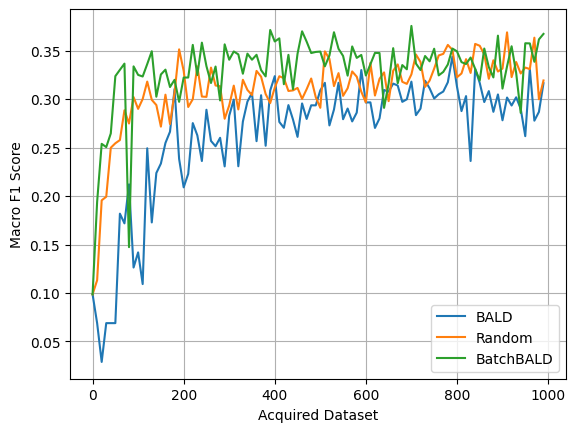

In [2]:
f1_bald = [0.09864499751917404, 0.06891480197499737, 0.028906627963231735, 0.06891480197499737, 0.06891480197499737, 0.06891480197499737, 0.18184603075439232, 0.17183546196793173, 0.2120672119665942, 0.1262636861602121, 0.14190703725728052, 0.10921353285726228, 0.24928642329189918, 0.17279453114452767, 0.22377379033617864, 0.23354696695625124, 0.2547828025370674, 0.26638238694882616, 0.31036646758528724, 0.23834392908430324, 0.20898787396571153, 0.2228866215201715, 0.2752590991344318, 0.26261850700292005, 0.23616259114387503, 0.2890172643880064, 0.256871175423773, 0.25138971447547215, 0.2600972271512259, 0.23059519404480674, 0.28286866826520496, 0.2995295302100614, 0.2307449058110561, 0.2768283322626289, 0.29744568258678866, 0.30631516528437597, 0.2566258726718916, 0.3040016487147928, 0.2518910483023295, 0.30887145943282673, 0.3237008767437115, 0.27648579306080995, 0.27042010443055176, 0.2938140290719576, 0.2790068217193841, 0.2610430025841454, 0.295553569961162, 0.2795553568764656, 0.29360585660236366, 0.2935683725677228, 0.30905841748656093, 0.31679521897084323, 0.2728589275135724, 0.289210395219584, 0.31686448214210544, 0.279266611575073, 0.29027825692771336, 0.27700215684724105, 0.28608377298867393, 0.3299748809149993, 0.29655112232535114, 0.2966402004713498, 0.2702779585764263, 0.2801083371306333, 0.3094262367137759, 0.3076233009484865, 0.3160212438661231, 0.31399098859958946, 0.2971714887113964, 0.2998213359121472, 0.31802975586951016, 0.2834654161072371, 0.29024609309585747, 0.3189832151885785, 0.3111635448821298, 0.3006544180357689, 0.30499489897393023, 0.30783813408737465, 0.3173944890268465, 0.34378831183644887, 0.3130191785851863, 0.28764266726685983, 0.3031290842968067, 0.23617449276517768, 0.3311323597945399, 0.3167111278526713, 0.2969731170693677, 0.30827099932423324, 0.28689568323150194, 0.30483933155554127, 0.2781559771957687, 0.30162468773585555, 0.29341223406335554, 0.30186144457146274, 0.29010132510135594, 0.26179046055591515, 0.33120636725193947, 0.277754008151536, 0.2868257556529878, 0.3164219437147564]
f1_random = [0.09864499751917404, 0.11316006547078328, 0.19559584454036857, 0.19929616027858832, 0.24985803537386705, 0.25445803736534817, 0.2577436991490614, 0.288508151005568, 0.27482966890724464, 0.3021292337689256, 0.28993346611872084, 0.30011876525627906, 0.318083912382988, 0.2992161633311599, 0.2938985426059681, 0.27160146782047817, 0.30456799829918013, 0.27426600750592567, 0.306745099113728, 0.3513206727445924, 0.3292048842759631, 0.29188301335670314, 0.2998880484735832, 0.3338053635196529, 0.3026344281652867, 0.3023106055891769, 0.3325266433677701, 0.31406747900533644, 0.31327803123573617, 0.27974861636812837, 0.2934708405307315, 0.3139195883337557, 0.2893279904602631, 0.31994181375213343, 0.30946238306500223, 0.30419309413587237, 0.3291029075522915, 0.3231481288989141, 0.3052472427570308, 0.29592401454589706, 0.31178093015524827, 0.32358943037770266, 0.32168673504543027, 0.30840977638557915, 0.3089888307724386, 0.3115370332108984, 0.30027509864583085, 0.3102231359810912, 0.32124079570633046, 0.301992341822236, 0.2910357241256411, 0.3492551099965602, 0.3415586738156271, 0.31341858906506764, 0.32680976983043053, 0.3033673400299051, 0.31117884510123967, 0.32854664412265866, 0.32313746338649213, 0.30761959322311994, 0.29659679320089416, 0.33730658239706063, 0.30368144527463786, 0.3208788654356925, 0.32757119922662986, 0.29790981176153963, 0.32926391418514495, 0.3357747908063882, 0.3178449934495749, 0.315710254194876, 0.32550493917303774, 0.3460346582092591, 0.3382819214273785, 0.3126019350666873, 0.3191288168757135, 0.3314663715111415, 0.3450745654930693, 0.3466807906296446, 0.35591070687951193, 0.35084398888468216, 0.3225135179000235, 0.32646183770011034, 0.3412134589766476, 0.3270002449940074, 0.356958070250384, 0.3550366227165315, 0.3461639163214047, 0.3209569261934408, 0.3400589126107621, 0.32843639196663393, 0.33149558144030195, 0.3688604974415164, 0.32269965952452656, 0.33826847799241944, 0.32644055422723756, 0.3325576115241137, 0.3309847184257399, 0.3633718661346723, 0.29985237478539656, 0.31924943248481413]
f1_batch_bald = [0.09864499751917404, 0.19408403095411697, 0.2538788945781422, 0.2505178520717049, 0.2646106906141766, 0.32369936775277247, 0.3302069205109096, 0.3366071851292398, 0.14729294098666032, 0.33377962699807046, 0.3249719487731673, 0.3233214105008618, 0.3361546779932055, 0.3493937805113321, 0.3024765475540782, 0.32542732902474075, 0.33040805287743324, 0.3124763142350827, 0.31990474101517735, 0.29718514317547073, 0.3222316735110647, 0.32227217332984553, 0.35592772736565914, 0.3248167292468586, 0.35823402752124295, 0.3340152516543231, 0.31663153577073705, 0.3336201698397465, 0.2986232647785225, 0.35651517263701216, 0.3406224525135366, 0.34916751983622274, 0.34617561897174626, 0.32618765147750334, 0.3468910307092119, 0.3406474298935512, 0.34571301375916574, 0.329921429529988, 0.32343320689159905, 0.3713369002729348, 0.359438640333582, 0.3626826325669183, 0.31538065991009984, 0.3456466267742957, 0.3102091162482784, 0.3467823937040337, 0.369934506983927, 0.3593046211625601, 0.34753928627328906, 0.34866723829524754, 0.34905178729360253, 0.3338066502484454, 0.3450152867946012, 0.36899344216207824, 0.35191603353870415, 0.34455475461685503, 0.32419534073716116, 0.3543363244524907, 0.3425211397539325, 0.34556082290589324, 0.32434807366588325, 0.33602883538283795, 0.3476788398949073, 0.34756697762657446, 0.2909916622396426, 0.31593692378864896, 0.3525440362372015, 0.31633796893491867, 0.33512315963208034, 0.33076071719567657, 0.3755037165337724, 0.3366994227046498, 0.3299807965137718, 0.34447352716563806, 0.33898212279625545, 0.35198420969148786, 0.3244898086505946, 0.32807726549835364, 0.3357359698340913, 0.35217848364953586, 0.34930436034561785, 0.33815923199006076, 0.336210282633842, 0.34289370276466485, 0.33123060092972495, 0.31920710935117264, 0.35219009635688087, 0.33295851175601293, 0.32237778237190573, 0.3654666072409847, 0.31086293254765024, 0.33377772820861784, 0.3545339061061676, 0.3270783435085209, 0.28582072035908107, 0.3576249258037225, 0.35746941424078854, 0.3385051863701971, 0.36161942466585467, 0.3672614808933273]


import matplotlib.pyplot as plt
plt.plot( [10*i for i in range(len(f1_bald))],f1_bald, label = "BALD")
plt.plot([10*i for i in range(len(f1_bald))],f1_random, label = "Random")
plt.plot([10*i for i in range(len(f1_bald))],f1_batch_bald, label =  "BatchBALD")
plt.xlabel("Acquired Dataset")
plt.ylabel("Macro F1 Score")
plt.legend(loc = "lower right")
plt.grid()